<a href="https://colab.research.google.com/github/LoneWolf132/email-priority-classifier1/blob/main/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git remote add origin https://github.com/LoneWolf132/email-priority-classifier.git
!git branch -M main
!git push -u origin main

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

#statistics inference
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
dataset_path='/content/drive/MyDrive/Colab Notebooks/dataset_08_email_priority_classification.csv'
df = pd.read_csv(dataset_path)

In [ ]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage (%)': (df.isnull().mean() * 100).round(2)
}).query("`Missing Count` > 0")
print(missing)

Empty DataFrame
Columns: [Missing Count, Percentage (%)]
Index: []


In [ ]:
sentinels = ['?', 'None', 'NA', 'null', '', -999, 999]
hidden_missing = {
    col: df[col].isin(sentinels).sum()
    for col in df.columns if df[col].isin(sentinels).sum() > 0
}
print("Hidden placeholders:", hidden_missing)

Hidden placeholders: {}


In [ ]:
exact_dupes = df.duplicated().sum()
print(f"Exact duplicates: {exact_dupes} ({exact_dupes / len(df) * 100:.2f}%)")

Exact duplicates: 0 (0.00%)


In [ ]:
target_col = 'target'

# Value counts with raw count and percentage
class_dist = pd.DataFrame({
    'Count': df[target_col].value_counts(dropna=False),
    'Proportion (%)': (df[target_col].value_counts(dropna=False, normalize=True) * 100).round(2)
})
print(class_dist)

        Count  Proportion (%)
target                       
1         500            50.0
0         500            50.0


In [ ]:
X = df.drop(columns=['target'])
y = df['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        penalty='l2',            # L2 (Ridge) shrinkage to stabilize weights
        C=1.0,                   # Default inverse regularization strength
        solver='lbfgs',          # Efficient quasi-Newton solver for small, dense tabular data
        class_weight=None,       # Classes are balanced (50:50); no re-weighting needed
        max_iter=1000,           # Ensures full convergence after standard scaling
        random_state=42          # Guarantees deterministic, reproducible results
    )
)

model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
print("Model Configuration:")
print(model.get_params())

Model Configuration:
{'memory': None, 'steps': [('standardscaler', StandardScaler()), ('logisticregression', LogisticRegression(max_iter=1000, random_state=42))], 'transform_input': None, 'verbose': False, 'standardscaler': StandardScaler(), 'logisticregression': LogisticRegression(max_iter=1000, random_state=42), 'standardscaler__copy': True, 'standardscaler__with_mean': True, 'standardscaler__with_std': True, 'logisticregression__C': 1.0, 'logisticregression__class_weight': None, 'logisticregression__dual': False, 'logisticregression__fit_intercept': True, 'logisticregression__intercept_scaling': 1, 'logisticregression__l1_ratio': None, 'logisticregression__max_iter': 1000, 'logisticregression__multi_class': 'deprecated', 'logisticregression__n_jobs': None, 'logisticregression__penalty': 'l2', 'logisticregression__random_state': 42, 'logisticregression__solver': 'lbfgs', 'logisticregression__tol': 0.0001, 'logisticregression__verbose': 0, 'logisticregression__warm_start': False}


Confusion Matrix:
 [[62 38]
 [30 70]]


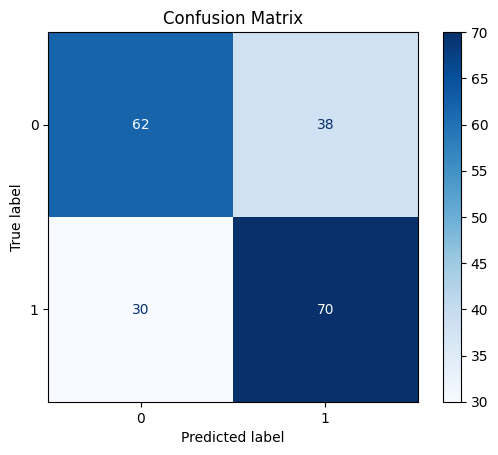


Classification Report:

              precision    recall  f1-score   support

           0     0.6739    0.6200    0.6458       100
           1     0.6481    0.7000    0.6731       100

    accuracy                         0.6600       200
   macro avg     0.6610    0.6600    0.6595       200
weighted avg     0.6610    0.6600    0.6595       200

ROC-AUC Score: 0.7343


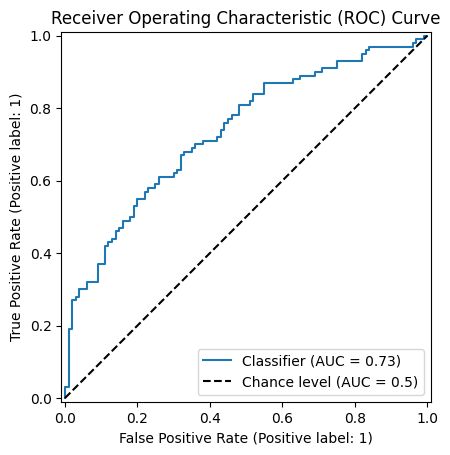

In [ ]:
y_pred = model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Display Confusion Matrix plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Evaluation of Metrics (Accuracy, Precision, Recall, F1-Score)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, digits=4))

y_prob = model.predict_proba(X_test)[:, 1]

#  ROC-AUC score
auc_score = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {auc_score:.4f}")

# Plot ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.show()

In [ ]:
classifier = model.named_steps['logisticregression']

# 2. Extract feature names, raw weights, and odds ratios
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Log-Odds)': classifier.coef_[0],
    'Odds Ratio (exp(coef))': np.exp(classifier.coef_[0])
}).sort_values(by='Coefficient (Log-Odds)', ascending=False)

# 3. Display the intercept and the coefficient table
print(f"Intercept (Beta 0): {classifier.intercept_[0]:.4f}\n")
print(coefficients.to_string(index=False))

Intercept (Beta 0): 0.0152

                Feature  Coefficient (Log-Odds)  Odds Ratio (exp(coef))
       attachment_count                0.703534                2.020881
       sender_frequency                0.670496                1.955207
          thread_length                0.642721                1.901648
 previous_priority_rate               -0.371861                0.689450
          keyword_score               -0.416070                0.659634
response_deadline_hours               -0.494929                0.609614


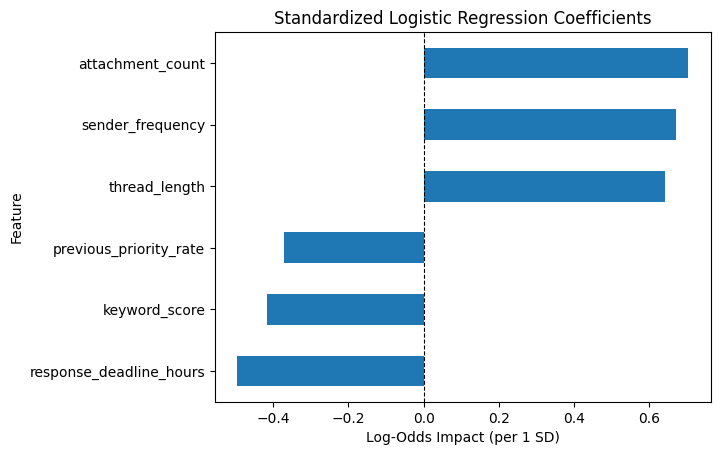

In [ ]:
coefficients.sort_values(by='Coefficient (Log-Odds)').plot(x='Feature', y='Coefficient (Log-Odds)', kind='barh', legend=False, title='Standardized Logistic Regression Coefficients', xlabel='Log-Odds Impact (per 1 SD)'); plt.axvline(0, color='black', linestyle='--', linewidth=0.8); plt.show()

In [ ]:
error_df = X_test.assign(actual=y_test, pred=y_pred, prob=y_prob).query("actual != pred").assign(error_type=lambda d: np.where(d.actual == 0, 'False Positive', 'False Negative')).groupby('error_type', as_index=False).apply(lambda g: g.sample(min(3, len(g)), random_state=42)).reset_index(drop=True); display(error_df[['error_type', 'prob', 'actual', 'pred', 'attachment_count', 'sender_frequency', 'response_deadline_hours', 'keyword_score']])

/tmp/ipykernel_904/1995913813.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  error_df = X_test.assign(actual=y_test, pred=y_pred, prob=y_prob).query("actual != pred").assign(error_type=lambda d: np.where(d.actual == 0, 'False Positive', 'False Negative')).groupby('error_type', as_index=False).apply(lambda g: g.sample(min(3, len(g)), random_state=42)).reset_index(drop=True); display(error_df[['error_type', 'prob', 'actual', 'pred', 'attachment_count', 'sender_frequency', 'response_deadline_hours', 'keyword_score']])


,error_type,prob,actual,pred,attachment_count,sender_frequency,response_deadline_hours,keyword_score
0,False Negative,0.185369,1,0,2,0,4.65,43.78
1,False Negative,0.099230,1,0,2,2,23.57,41.33
2,False Negative,0.359312,1,0,4,0,5.12,51.71
3,False Positive,0.535643,0,1,1,4,3.29,45.12
4,False Positive,0.541944,0,1,3,2,6.50,22.07
5,False Positive,0.588066,0,1,5,1,11.55,35.71
